In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.insert(0, project_root)

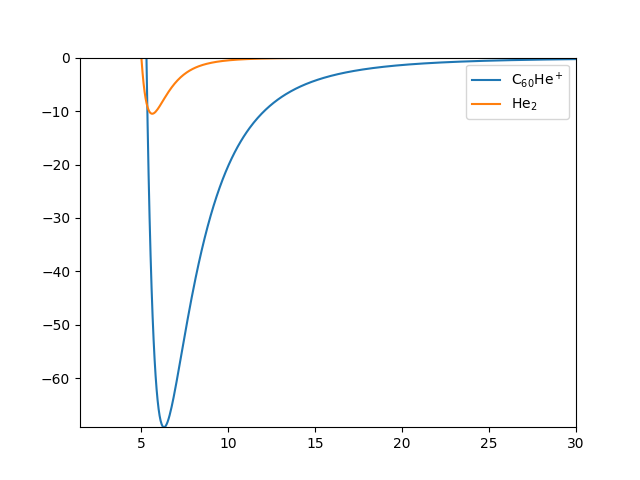

In [2]:
# Define potentials 
from tbr.potentials import LJ, dLJ, He2_V, He2_dV
from tbr.constants import ANG2BOH, K2HAR

# He + He + C60+ -> C60He+ + He

C60pHe_de = 0.000219069

He_alpha = 0.208*(ANG2BOH**3) # A^3
C60pHe_c4 = He_alpha/2
C60pHe_c8 = C60pHe_c4**2/(4*C60pHe_de)


v_C60pHe = LJ(n=4, m=8, cn = C60pHe_c4, cm = C60pHe_c8)
dv_C60pHe = dLJ(n=4, m=8, cn = C60pHe_c4, cm = C60pHe_c8)

v_He2 = He2_V()
dv_He2 = He2_dV()


# N2 + N2p + He
v_funcs = (v_He2, v_C60pHe, v_C60pHe)
dv_funcs = (dv_He2, dv_C60pHe, dv_C60pHe)


# Plot potentials
x = np.linspace(1.3, 30, 500)
y_He2 = v_He2(x)/K2HAR
plt.figure()
plt.plot(x, v_C60pHe(x)/K2HAR, label = r'C$_{60}$He$^+$')
plt.plot(x, y_He2, label = r'He$_2$')
plt.xlim(1.5, 30)
plt.ylim(min(v_C60pHe(x))/K2HAR, 1e-2) # C60He+
# plt.ylim(min(v_N2pHe(x))/K2HAR, 1e-2) # N2+He
# plt.ylim(min(v_N2He(x))/K2HAR, 1e-2) # N2He
plt.legend()
plt.show()

In [3]:
masses = (4.0026, 4.0026, 60*12.011) # He, He, C60+
m1, m2, m3 = masses
E0 = 1 # Kelvin
R0 = 1000.0
dR0 = 0.1*R0
b0 = 0

In [4]:
# Simulate one trajectory
from tbr.simulator import run_trajectory_worker
import time

seed = int(np.random.random()*8923)
print(f'Running trajectory with seed {seed}...')
t_stop, r_stop, r_tol, a_tol = 3, 3, 1e-08, 1e-10 # (1e-11, 1e-13)
task_data = m1, m2, m3, E0, b0, R0, v_funcs, dv_funcs, seed
t0 = time.time()
solution = run_trajectory_worker(task_data=task_data)
tf = time.time()
print(f'Trajectory run in {tf-t0} s')

Running trajectory with seed 260...
Energy drift 3.0505825611497036e-13 Hartree
Trajectory run in 9.616974353790283 s


[0 0 0 1 0]


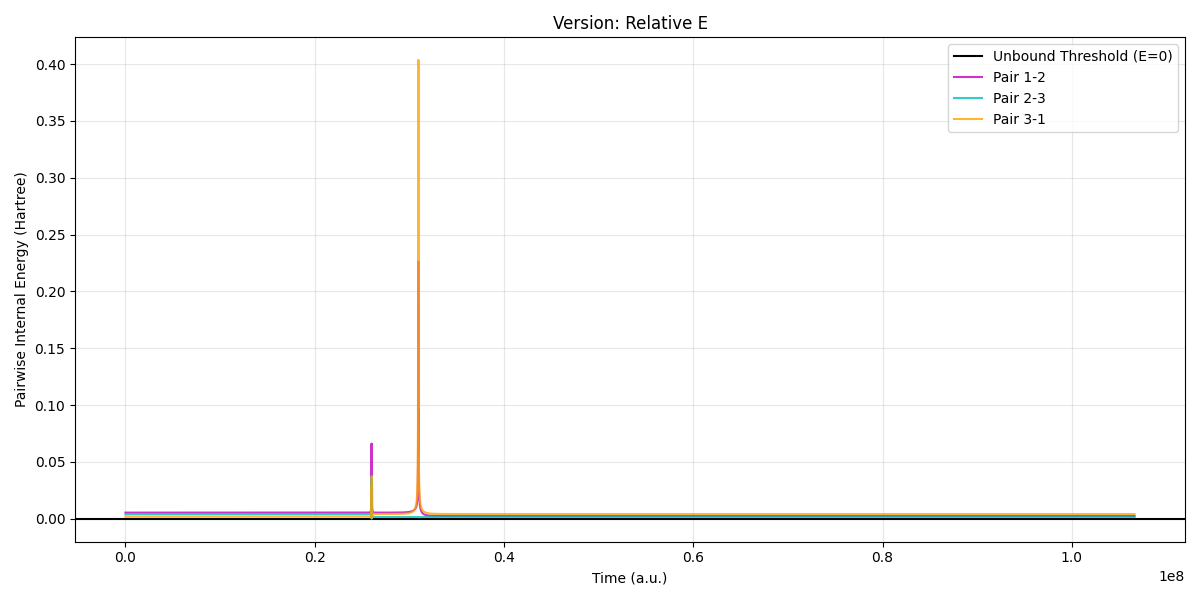

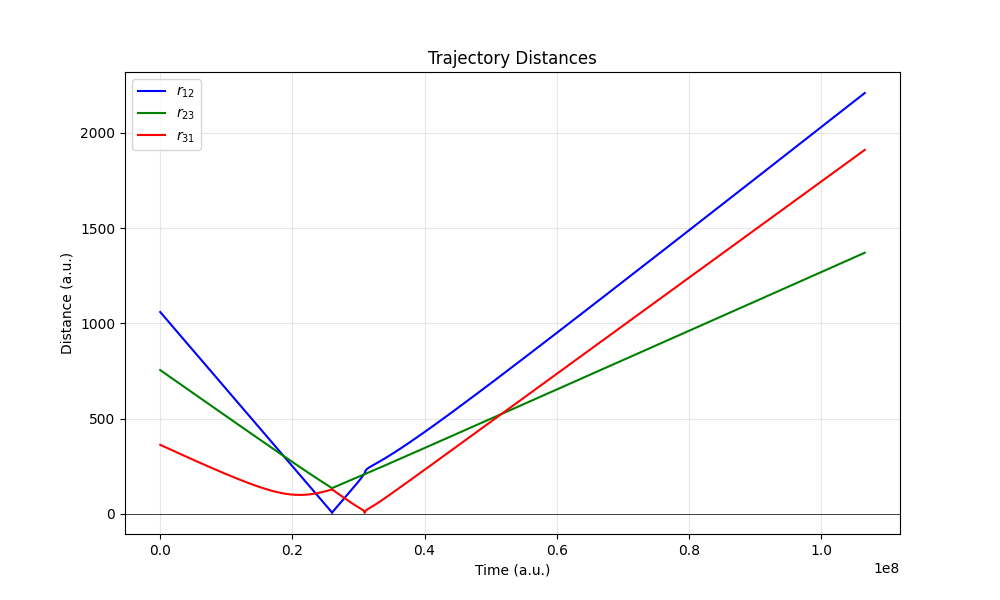

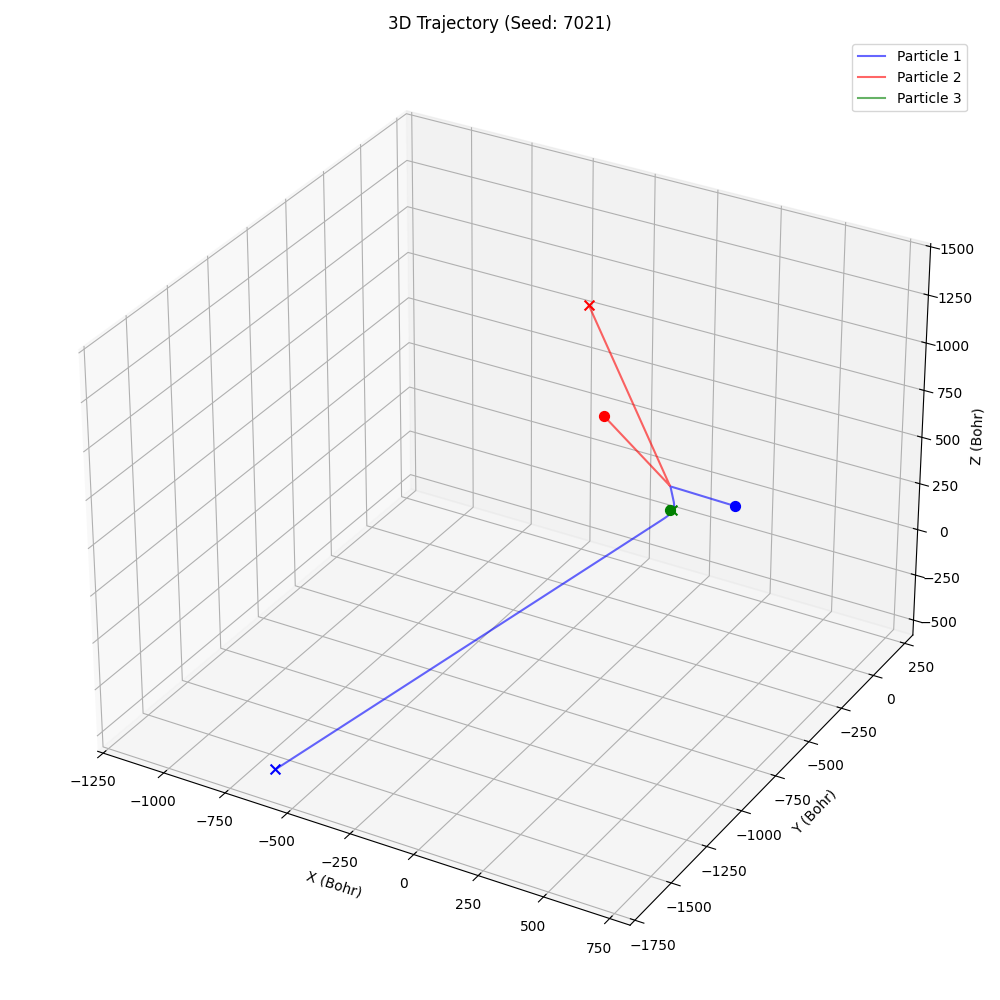

In [10]:
# Plot
from tbr.simulator import get_distances_from_solution
from tbr.plotters import plot_distances, plot_3d_motion, plot_relative_e

# Observables
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']

r12, r23, r31 = get_distances_from_solution(
            np.vstack([rho_vec, p_vec]), m1, m2
        )

data_block = np.vstack([
            solution['times'], 
            r12, r23, r31,
            solution['positions_rho'], 
            solution['momenta_p']
        ]).T

print(n_res)
# print(rho_vec)
plot_distances(data_block, seed, E0, b0)
# plot_2d_motion(data_block, seed)
plot_3d_motion(data_block, m1, m2, m3, seed)
plot_relative_e(solution, masses, v_funcs)
# plot_energy_trace(solution, masses, v_funcs)
# animate_3d_forces(solution, masses, dv_funcs, scale = 0,
#                   filename='trajectory_forces7.gif', duration_seconds=10,
#                   azim=0,elev=30)
plt.show()

Running trajectory with seed 28612...
Energy drift 4.587681158713244e-12 Hartree
Trajectory run in 0.18184280395507812 s
Running trajectory with seed 28599...
Energy drift 1.2768665591442717e-12 Hartree
Trajectory run in 0.1981182098388672 s
Running trajectory with seed 28785...
Energy drift 2.944918896160962e-11 Hartree
Trajectory run in 0.16216397285461426 s
Running trajectory with seed 27001...
Energy drift 8.915335778094069e-12 Hartree
Trajectory run in 0.2547922134399414 s
Running trajectory with seed 24293...
Energy drift 4.550601679889399e-12 Hartree
Trajectory run in 0.19936108589172363 s
Running trajectory with seed 30766...
Energy drift 9.040751464519173e-12 Hartree
Trajectory run in 0.16557860374450684 s
Running trajectory with seed 26791...
Energy drift 1.0227520605865948e-11 Hartree
Trajectory run in 0.27724194526672363 s
Running trajectory with seed 31105...
Energy drift 9.204487587245958e-12 Hartree
Trajectory run in 0.2875785827636719 s
Running trajectory with seed 2865

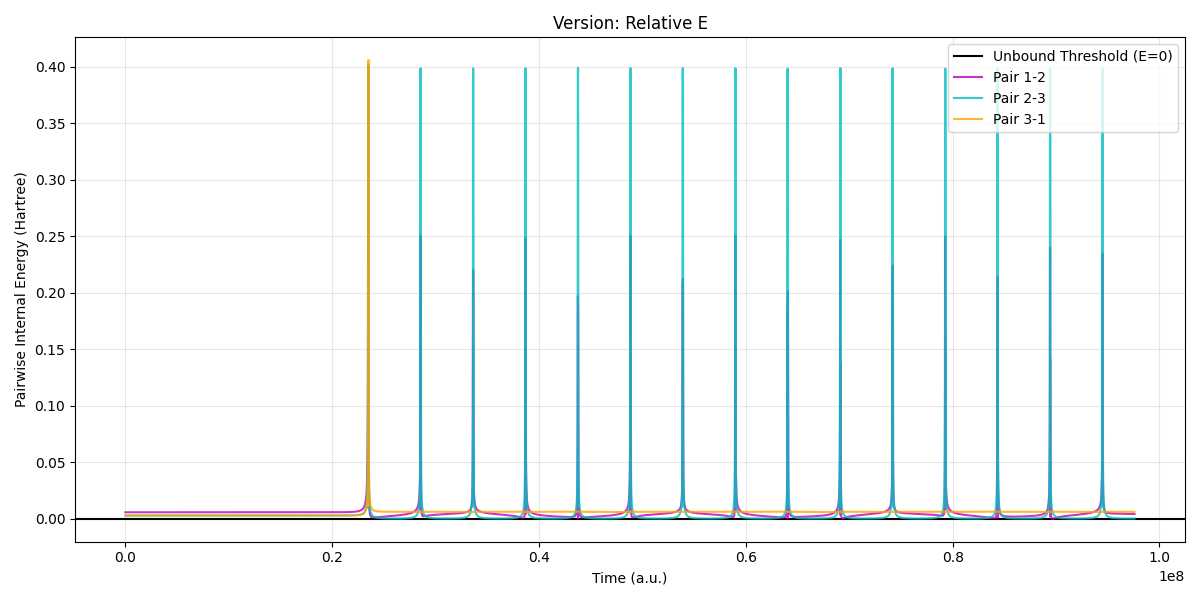

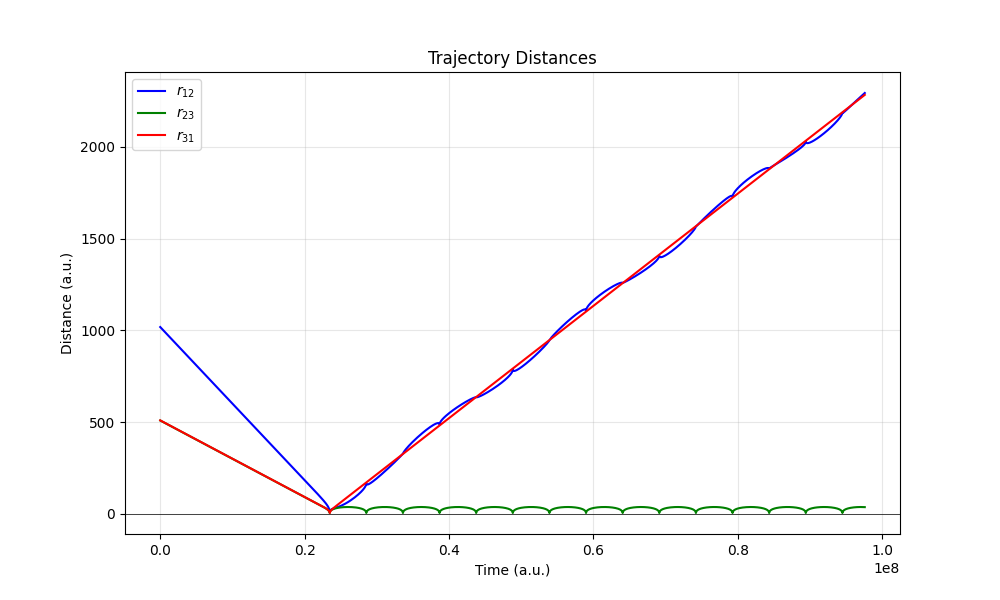

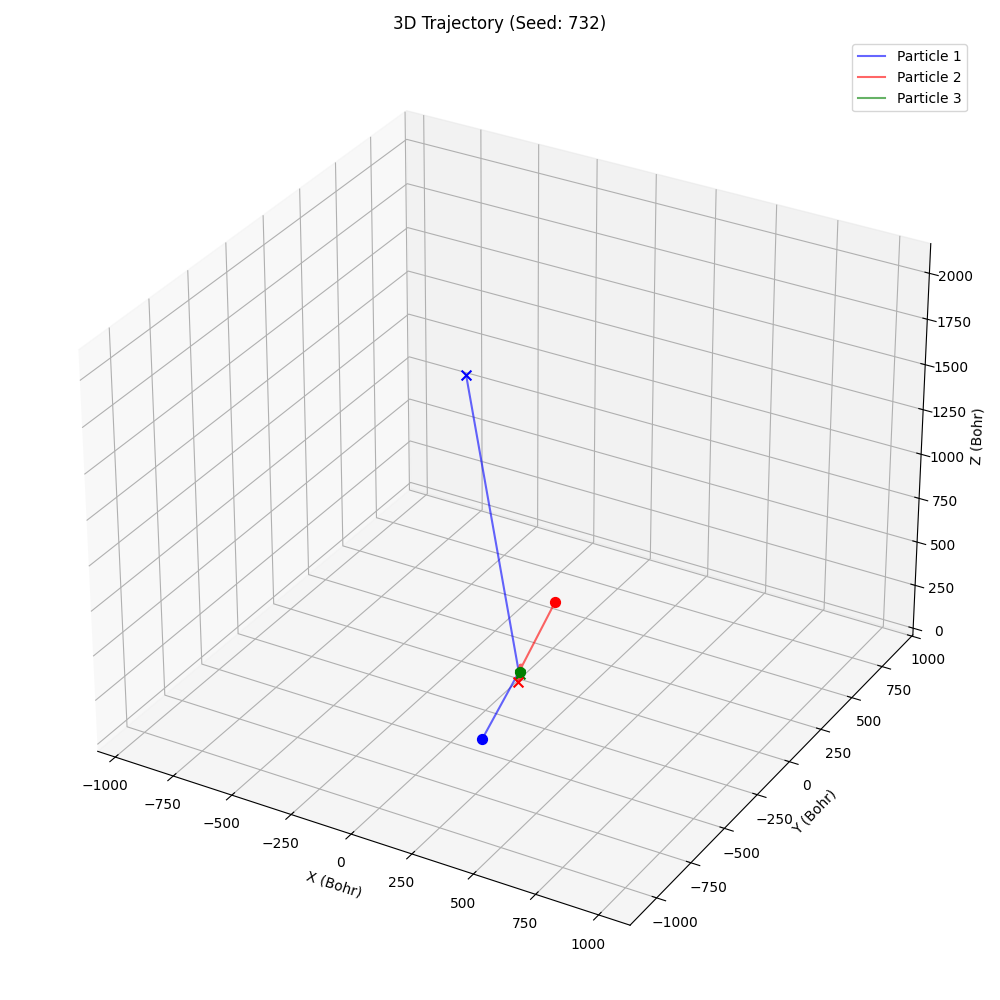

In [ ]:
# Simulate until a reaction is found. 
t_stop, r_stop, r_tol, a_tol = 3, 3, 1e-08, 1e-10 # (1e-11, 1e-13)
task_data = m1, m2, m3, E0, b0, R0, dR0, v_funcs, dv_funcs, t_stop, r_stop, r_tol, a_tol, seed
def run_t():
    seed = int(np.random.random()*8923) + 23013
    print(f'Running trajectory with seed {seed}...')
    t_stop, r_stop, r_tol, a_tol = 3, 3, 1e-08, 1e-10 # (1e-11, 1e-13)
    task_data = m1, m2, m3, E0, b0, R0, dR0, v_funcs, dv_funcs, t_stop, r_stop, r_tol, a_tol, seed
    t0 = time.time()
    solution = run_trajectory_worker(task_data=task_data)
    tf = time.time()
    print(f'Trajectory run in {tf-t0} s')
    
    return solution

solution = run_t()
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']

while (n_res[3] == 1): # search for non-dissociative trajectories 
    solution = run_t()
    n_res = solution['n_res']
    times = solution['times']
    rho_vec = solution['positions_rho']
    p_vec = solution['momenta_p']

r12, r23, r31 = get_distances_from_solution(
            np.vstack([rho_vec, p_vec]), m1, m2
        )

data_block = np.vstack([
            solution['times'], 
            r12, r23, r31,
            solution['positions_rho'], 
            solution['momenta_p']
        ]).T
print(n_res)
plot_distances(data_block, seed, E0, b0)
# plot_2d_motion(data_block, seed)
plot_3d_motion(data_block, m1, m2, m3, seed)
plot_relative_e(solution, masses, v_funcs)
# plot_energy_trace(solution, masses, v_funcs)
# animate_3d_forces(solution, masses, dv_funcs, scale = 0,
#                   filename='trajectory_forces7.gif', duration_seconds=10,
#                   azim=0,elev=30)
plt.show()

In [4]:
import seaborn as sns

def plot_opac(df, energies, suffix='BB', fmt = '.', label = None, save_path=None):
    # plt.figure()
    # colors = plt.cm.viridis(np.linspace(0,1,len(energies)))
    
    colors = sns.color_palette('deep', len(energies))

    for i, e_val in enumerate(energies):
        subset = df[df['e'] == e_val].sort_values('b')

        if subset.empty:
            print(f'Skipping E = {e_val}: No data found.')
            continue
        
        plt.errorbar(subset['b'], subset[f'p_{suffix}'], yerr=subset[f'p_{suffix}_err'],
                        fmt = fmt, capsize=3, label=f'{label}, E = {e_val} K', color = colors[i])
        
        if f'bmax_{suffix}' in df.columns:
            bmax = df[df['e'] == e_val].sort_values('b')[f'bmax_{suffix}'].values[0]
            plt.axvline(bmax, 0, 1, color = colors[i])
    
    plt.xlabel('Impact Parameter ($a_0$)')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout
    if save_path:
        plt.savefig(save_path)
        print(f'Plot saved: {save_path}')

In [11]:
from tbr.analysis import opacity, cross_section, rate
from tbr.constants import U2ME

in_file = 'results/c60_short.txt'

masses = (4.0026, 4.0026, 60*12.011) # He, He, C60+

m1, m2, m3 = masses
mu0 = np.sqrt(m1*m2*m3/(m1+m2+m3))
m12 = m1*m2/(m1+m2)
tolerance_numerator = 10
window_size = 3
tolerances = {'AA': 10, 'AB': 38}
windows = {'AA': 3, 'AB': 3}

opac = opacity(in_file, masses)
sigma = cross_section(opac, masses, tolerances=tolerances, windows=windows)
k3 = rate(opac, mu0, masses, windows=windows, tolerances=tolerances)
# opac = opac_bmax(in_file, tolerance_numerator=tolerance_numerator, window_size=window_size)
# sigma = cross_section(in_file, tol_num=tolerance_numerator, window_size=window_size)
# k3 = rate(in_file, mu0=mu0, tol_num=tolerance_numerator, window_size=window_size)


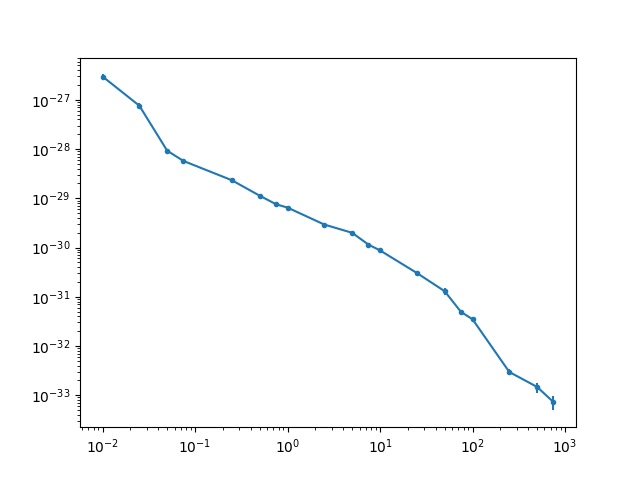

In [12]:
rates = k3.copy()
rates = rates[rates['e'] < 1000]

plt.figure()
plt.errorbar(rates['e'], rates['k_AB'], rates['k_AB_err'], marker='.')
plt.xscale('log')
plt.yscale('log')

In [21]:
rates.loc[:,['e','sig_AB', 'sig_AB_err','k_AB','k_AB_err']].to_csv('c60_rates.csv', index=False)

In [20]:
# Visualize bmax and opacity
e_list = [0.075]
# colors = sns.color_palette('deep', len(e_list))
colors = plt.cm.viridis()
plt.figure()
for i,e_val in enumerate(e_list):
    opacplt = opac[opac['e']==e_val]
    bmax_AB = k3[k3['e']==e_val]['bmax_AB'].values[0]
    plt.errorbar(opacplt['b'], opacplt['p_AB'], opacplt['p_AB_err'], fmt = 'o', color = colors[i], alpha = 0.6, label = f'{e_val:.2f} K')
    plt.axvline(bmax_AB, 0, 1, linestyle='--', color = colors[i])
    plt.title('V')
plt.legend()

TypeError: Colormap.__call__() missing 1 required positional argument: 'X'

Text(0, 0.5, 'Rate (cm$^6$/s)')

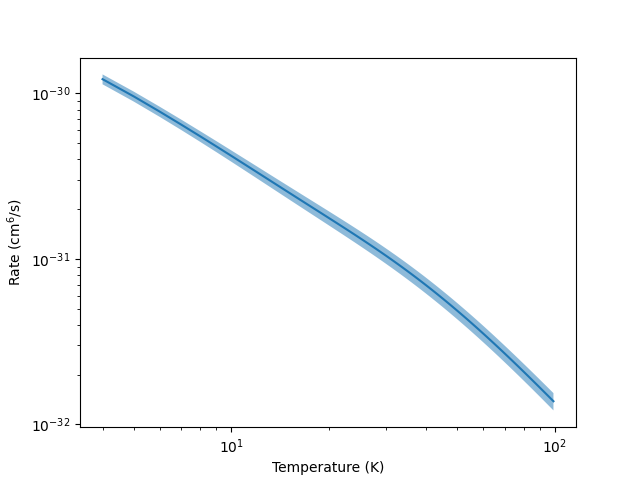

In [94]:
from tbr.analysis import thermal_rate
t_vals = np.arange(4, 100, 1)
tr = thermal_rate(rate, t_vals, 'AB')
plt.figure()
plt.plot(tr['T_K'], tr['k_thermal_AB'])
plt.fill_between(tr['T_K'], 
                 tr['k_thermal_AB'] - tr['k_thermal_AB_err'], tr['k_thermal_AB'] + tr['k_thermal_AB_err'],
                 alpha = 0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel(r'Rate (cm$^6$/s)')

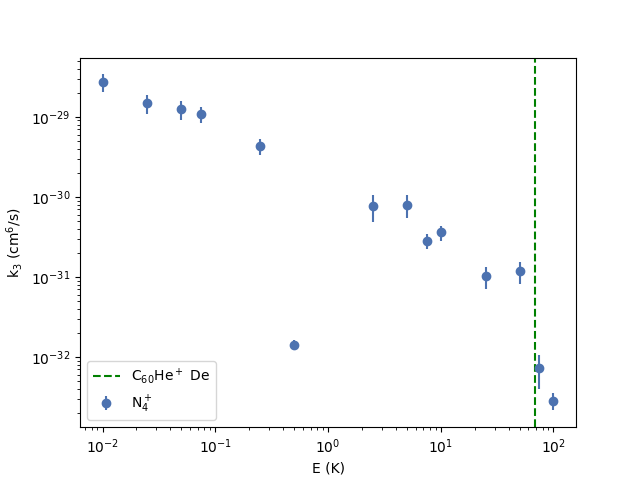

In [26]:
plt.figure()
plt.errorbar(k3['e'], k3['k_BB'], k3['k_BB_err'], fmt='o', color=colors[0], label=r'N$_4^+$')
plt.axvline(C60pHe_de/K2HAR,0,1, linestyle = '--', color = 'g', label = r'C$_{60}$He$^+$ De')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('k$_3$ (cm$^6$/s)')
plt.xlabel('E (K)')
plt.legend()